# Statistics and Financial Data Analysis - Problem Sheet 2

In [116]:
import pandas_datareader as pd_data
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
import math
import statsmodels.api as sm
import scipy as sp

## Problem 1: Data Analysis Report

In [140]:
df = pd.read_csv('Unemployment.csv')
df.set_index('Year',inplace = True)
df.rename(columns = {'Rate':'unemployment_rate'},inplace = True)
df.head()

,unemployment_rate
Year,
1971,4.1
1972,4.3
1973,3.7
1974,3.7
1975,4.5


In [141]:
df2 = pd.read_csv('Repossession.csv')
df2.head()

,year,num_mortage,num_possession
0,1969,"4,017,000","3,370"
1,1970,"4,171,000","3,760"
2,1971,"4,506,000","2,800"
3,1972,"4,770,000","1,760"
4,1973,"4,862,000","1,220"


In [142]:
df2['num_possession'] = df2['num_possession'].str.replace(',', '').astype(float)
df2['num_mortage'] = df2['num_mortage'].str.replace(',', '').astype(float)
df2['repossession_rate'] = df2['num_possession']/df2['num_mortage'] * 100
df2.rename(columns = {'year':'Year'},inplace = True)

In [143]:
df2.set_index('Year',inplace = True)
df2.head()

,num_mortage,num_possession,repossession_rate
Year,,,
1969,4017000.0,3370.0,0.083893
1970,4171000.0,3760.0,0.090146
1971,4506000.0,2800.0,0.062139
1972,4770000.0,1760.0,0.036897
1973,4862000.0,1220.0,0.025093


In [144]:
df3 = pd.read_csv('IR.csv')
df3.head()

,DATE,RATE
0,31 Dec 1975,11.0000
1,31 Dec 1976,11.1137
2,31 Dec 1977,8.8772
3,31 Dec 1978,9.1059
4,31 Dec 1979,13.6863


In [145]:
df3.rename(columns = {'DATE':'Year'}, inplace = True)
df3.head()

,Year,RATE
0,31 Dec 1975,11.0000
1,31 Dec 1976,11.1137
2,31 Dec 1977,8.8772
3,31 Dec 1978,9.1059
4,31 Dec 1979,13.6863


In [146]:
df3['Year'] = df3['Year'].str.replace('31 Dec ', '').astype(int)
df3.set_index('Year',inplace = True)
df3.head()

,RATE
Year,
1975,11.0000
1976,11.1137
1977,8.8772
1978,9.1059
1979,13.6863


In [147]:
df['interest_rate'] = df3['RATE']
df['repossession_rate'] = df2['repossession_rate']
df

,unemployment_rate,interest_rate,repossession_rate
Year,,,
1971,4.1,NaN,0.062139
1972,4.3,NaN,0.036897
1973,3.7,NaN,0.025093
1974,3.7,NaN,0.067006
1975,4.5,11.0000,0.095942
1976,5.4,11.1137,0.093010
1977,5.6,8.8772,0.083841
1978,5.5,9.1059,0.070047
1979,5.4,13.6863,0.048036


In [148]:
df = df.loc[(df.index >= 1975) & (df.index <=2013)]
df.head(3)

,unemployment_rate,interest_rate,repossession_rate
Year,,,
1975,4.5,11.0000,0.095942
1976,5.4,11.1137,0.093010
1977,5.6,8.8772,0.083841


In [149]:
df.tail(3)

,unemployment_rate,interest_rate,repossession_rate
Year,,,
2011,8.1,0.5,0.327653
2012,8.0,0.5,0.300425
2013,7.6,0.5,0.258359


Text(0, 0.5, 'Rates')

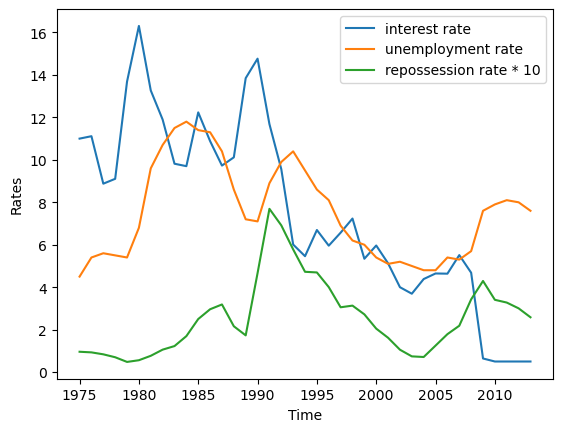

In [150]:
plt.plot(df['interest_rate'], label = 'interest rate')
plt.plot(df['unemployment_rate'], label = 'unemployment rate')
plt.plot(df['repossession_rate']*10, label = 'repossession rate * 10')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Rates')


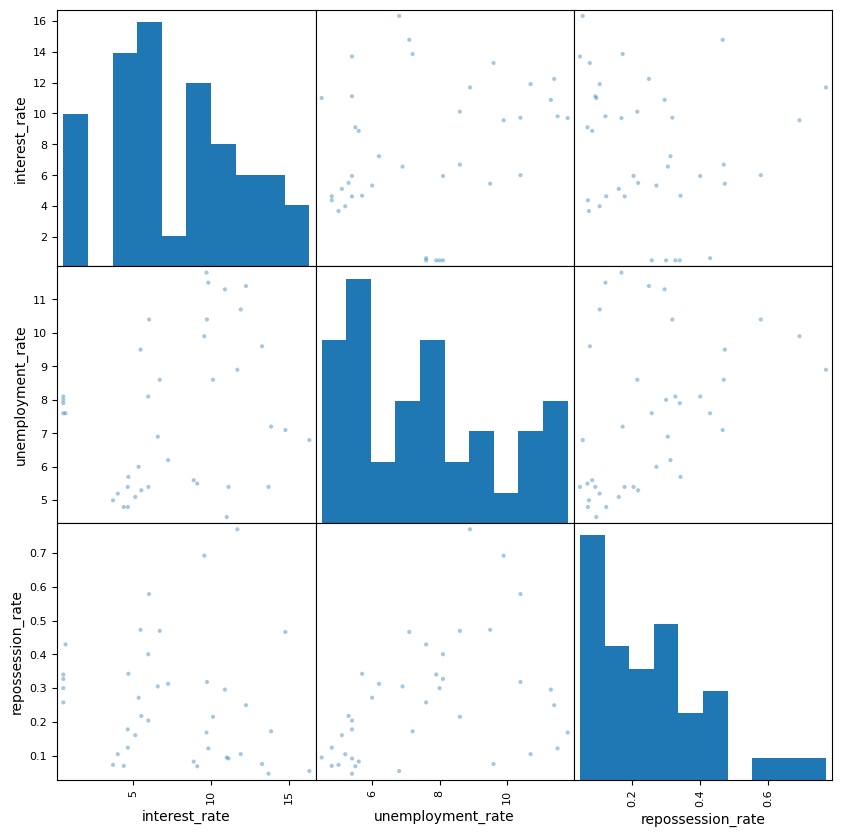

In [151]:
Rates_plot = df[['interest_rate','unemployment_rate','repossession_rate']]
pd.plotting.scatter_matrix(Rates_plot, alpha = 0.4, figsize= (10,10));

In [152]:
Rates_plot.corr()

,interest_rate,unemployment_rate,repossession_rate
interest_rate,1.000000,0.242834,-0.147038
unemployment_rate,0.242834,1.000000,0.402572
repossession_rate,-0.147038,0.402572,1.000000


In [159]:
#try linear regression
X_lr = df[['unemployment_rate','repossession_rate']]
X_lr = sm.add_constant(X_lr)
Y = df['interest_rate']
model_lr = sm.OLS(Y,X_lr).fit()

Y_lr = model_lr.predict(X_lr)
model_lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          interest_rate   R-squared:                       0.130
Model:                            OLS   Adj. R-squared:                  0.082
Method:                 Least Squares   F-statistic:                     2.701
Date:                Mon, 07 Nov 2022   Prob (F-statistic):             0.0807
Time:                        11:51:15   Log-Likelihood:                -108.90
No. Observations:                  39   AIC:                             223.8
Df Residuals:                      36   BIC:                             228.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 4.2213      2.337      1.806      0.079      -0.518       8.960
unemployment_rate     0.6913      0.326      2.123      0.041       0.031       1.352
repossession_rate    -7.0781      4.113     -1.721      0.094     -15.421       1.264
==============================================================================
Omnibus:                        0.304   Durbin-Watson:                   0.302
Prob(Omnibus):                  0.859   Jarque-Bera (JB):                0.274
Skew:                           0.182   Prob(JB):                        0.872
Kurtosis:                       2.812   Cond. No.                         49.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [187]:
u1 = df['unemployment_rate']
u2 = np.power(u1,2)
u3 = np.power(u1,3)

r1 = df['repossession_rate']
r2 = np.power(r1,2)

x_poly = pd.DataFrame([u1,u2,u3,u4,r1,r2]).T
x_poly.columns=['u1','u2','u3','u4','r1','r2']
x_poly.head()

,u1,u2,u3,u4,r1,r2
Year,,,,,,
1975,4.5,20.25,91.125,410.0625,0.095942,0.009205
1976,5.4,29.16,157.464,850.3056,0.093010,0.008651
1977,5.6,31.36,175.616,983.4496,0.083841,0.007029
1978,5.5,30.25,166.375,915.0625,0.070047,0.004907
1979,5.4,29.16,157.464,850.3056,0.048036,0.002307


In [188]:
#try polynomial regression 
X_pr = x_poly[['r1','r2']]
X_pr = sm.add_constant(X_pr)
Y = df['interest_rate']

model_pr = sm.OLS(Y,X_pr).fit()
y_fitted_pr = model_pr.predict(X_pr)

model_pr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          interest_rate   R-squared:                       0.203
Model:                            OLS   Adj. R-squared:                  0.159
Method:                 Least Squares   F-statistic:                     4.580
Date:                Mon, 07 Nov 2022   Prob (F-statistic):             0.0169
Time:                        21:53:56   Log-Likelihood:                -107.21
No. Observations:                  39   AIC:                             220.4
Df Residuals:                      36   BIC:                             225.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.3353      1.746      7.067      0.000       8.795      15.876
r1           -35.8325     11.843     -3.026      0.005     -59.851     -11.814
r2            46.3452     16.201      2.861      0.007      13.487      79.203
==============================================================================
Omnibus:                        0.685   Durbin-Watson:                   0.372
Prob(Omnibus):                  0.710   Jarque-Bera (JB):                0.773
Skew:                           0.193   Prob(JB):                        0.679
Kurtosis:                       2.429   Cond. No.                         32.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [181]:
X_pr

,const,r1,r2
Year,,,
1975,1.0,0.095942,0.009205
1976,1.0,0.093010,0.008651
1977,1.0,0.083841,0.007029
1978,1.0,0.070047,0.004907
1979,1.0,0.048036,0.002307
1980,1.0,0.056039,0.003140
1981,1.0,0.076862,0.005908
1982,1.0,0.105861,0.011206
1983,1.0,0.122699,0.015055


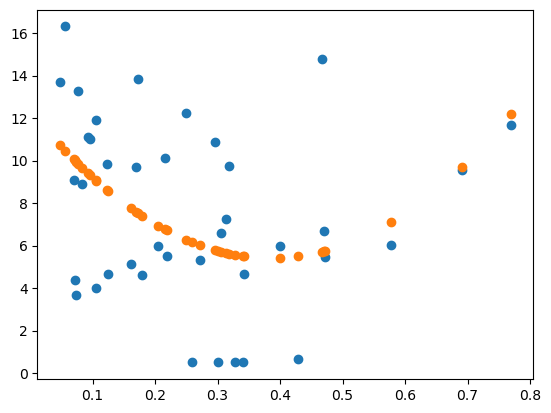

In [182]:
plt.scatter(X_pr['r1'], Y)
plt.scatter(X_pr['r1'], y_fitted_pr)

In [189]:
def pielinear(x, knots, p):
    n = len(knots) 
    res = x**0
    for i in np.arange(1,p+1):
        res = np.vstack((res, x**(i)))
    nullArray = np.zeros(len(x))
    for i in np.arange(0,n):
        res = np.vstack((res,np.maximum((x-knots[i])**p,nullArray)))
    return res